In [47]:
import os
import pandas as pd
import numpy as np
import pickle
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [48]:
def parse_fingering_file(file_path):
    """
    解析单个 fingering 文件，返回包含所有音符信息的列表。
    """
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            # 去除首尾空白字符并按空格分割
            parts = line.strip().split()
            if len(parts) < 8:
                continue  # 跳过格式不完整的行
            note_id = parts[0]
            onset_time = float(parts[1])
            offset_time = float(parts[2])
            spelled_pitch = parts[3]
            onset_velocity = float(parts[4])
            offset_velocity = float(parts[5])
            channel = int(parts[6])
            finger_number = parts[7]
            
            # 处理指法替换（例如 '3_1'）
            if '_' in finger_number:
                finger_number = finger_number.split('_')[0]  # 仅取主要指法
            
            # 转换指法为整数
            try:
                finger_number = int(finger_number)
            except ValueError:
                finger_number = None  # 处理无法转换的指法
            
            # 解析音高和八度
            pitch_name = ''.join([c for c in spelled_pitch if c.isalpha() or c in ['#', 'b']])
            octave = ''.join([c for c in spelled_pitch if c.isdigit()])
            octave = int(octave) if octave else 4  # 默认八度为4
            
            # 确定手部
            hand = 'right' if channel == 0 else 'left'
            
            # 计算音符持续时间
            duration = offset_time - onset_time
            
            data.append({
                'note_id': note_id,
                'onset_time': onset_time,
                'offset_time': offset_time,
                'spelled_pitch': spelled_pitch,
                'pitch_name': pitch_name,
                'octave': octave,
                'duration': duration,
                'hand': hand,
                'finger_number': finger_number
            })
    return data

In [50]:
def load_pig_dataset(fingering_dir):
    """
    加载 PIG Dataset 中所有 fingering 文件，返回一个包含所有音符数据的 DataFrame。
    """
    all_data = []
    for file_name in os.listdir(fingering_dir):
        if file_name.endswith('.txt'):
            file_path = os.path.join(fingering_dir, file_name)
            piece_data = parse_fingering_file(file_path)
            all_data.extend(piece_data)
    df = pd.DataFrame(all_data)
    return df

def get_midi_number(spelled_pitch):
    """
    将拼写音高（如 C4, D#5）转换为 MIDI 编号。
    A4 ≈ 440Hz 对应 MIDI 69。
    """
    import re
    match = re.match(r'^([A-Ga-g][#b]?)(\d+)$', spelled_pitch)
    if not match:
        return 60  # 默认C4
    pitch, octave = match.groups()
    octave = int(octave)
    note_to_semitone = {'C': 0, 'C#': 1, 'Db': 1,
                        'D': 2, 'D#': 3, 'Eb': 3,
                        'E': 4, 'Fb': 4,
                        'F': 5, 'F#': 6, 'Gb': 6,
                        'G': 7, 'G#': 8, 'Ab': 8,
                        'A': 9, 'A#': 10, 'Bb': 10,
                        'B': 11, 'Cb': 11}
    semitone = note_to_semitone.get(pitch, 0)
    midi_number = 12 * (octave + 1) + semitone
    return midi_number

# 设置 fingering 文件夹路径
fingering_folder = 'PIGdata/FingeringFiles'  # 请根据实际路径调整

# 加载数据
df = load_pig_dataset(fingering_folder)

# 查看数据
print(df.head())

  note_id  onset_time  offset_time spelled_pitch pitch_name  octave  duration  \
0       0    0.004883     0.248048            E4          E       4  0.243165   
1       1    0.004883     0.133302           G#3         G#       3  0.128419   
2       2    0.141114     0.255373            B3          B       3  0.114259   
3       3    0.263185     0.376955            A3          A       3  0.113770   
4       4    0.384768     0.503421           G#3         G#       3  0.118653   

    hand  finger_number  
0  right              1  
1   left             -3  
2   left             -1  
3   left             -2  
4   left             -3  


In [51]:
# 删除指法缺失的音符
df = df.dropna(subset=['finger_number'])

# 确保指法为整数类型
df['finger_number'] = df['finger_number'].astype(int)

# 计算 MIDI 编号
df['midi_number'] = df['spelled_pitch'].apply(get_midi_number)

# 初始化 LabelEncoder
le_pitch = LabelEncoder()
le_duration = LabelEncoder()
le_hand = LabelEncoder()
le_fingering = LabelEncoder()

# 对类别特征进行标签编码
df['pitch_encoded'] = le_pitch.fit_transform(df['spelled_pitch'])
df['duration_encoded'] = le_duration.fit_transform(df['duration'].astype(str))
df['hand_encoded'] = le_hand.fit_transform(df['hand'])

# 对目标标签进行标签编码
df['fingering_encoded'] = le_fingering.fit_transform(df['finger_number'])

# 特征和标签
X = df[['pitch_encoded', 'duration_encoded', 'hand_encoded']].values
y = df['fingering_encoded'].values

print(f"特征形状: {X.shape}")
print(f"标签形状: {y.shape}")

特征形状: (100040, 3)
标签形状: (100040,)


In [52]:
# 保存 LabelEncoder
with open('le_pitch.pkl', 'wb') as f:
    pickle.dump(le_pitch, f)

with open('le_duration.pkl', 'wb') as f:
    pickle.dump(le_duration, f)

with open('le_hand.pkl', 'wb') as f:
    pickle.dump(le_hand, f)

with open('le_fingering.pkl', 'wb') as f:
    pickle.dump(le_fingering, f)

sequence_length = 10  # 使用前10个音符预测第11个音符

def create_sequences(X, y, seq_length):
    X_seq = []
    y_seq = []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X, y, sequence_length)

print(f"序列特征形状: {X_seq.shape}")  # (样本数, sequence_length, 特征数量)
print(f"序列标签形状: {y_seq.shape}")  # (样本数,)

序列特征形状: (100030, 10, 3)
序列标签形状: (100030,)


In [53]:
# 划分训练集和验证集
X_train, X_val, y_train, y_val = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq
)

print(f"训练集样本数: {X_train.shape[0]}")
print(f"验证集样本数: {X_val.shape[0]}")

训练集样本数: 80024
验证集样本数: 20006


In [54]:
# 将序列数据保存为 npy 文件
np.save('X_train.npy', X_train)
np.save('X_val.npy', X_val)
np.save('y_train.npy', y_train)
np.save('y_val.npy', y_val)

## 特征工程

In [55]:
def calculate_midi_diff(df):
    df = df.copy()
    df['prev_midi_number'] = df['midi_number'].shift(1).fillna(60)  # 默认C4
    df['midi_diff'] = df['midi_number'] - df['prev_midi_number']
    
    # 假设有一个 'is_chord' 列标识当前音符是否为和弦的一部分
    # 如果没有，需要根据您的数据进行相应处理
    # 这里我们简单假设 'chord' 列已经存在并表示是否为和弦
    if 'chord' not in df.columns:
        df['chord'] = 0  # 默认不是和弦，可以根据实际数据调整
    
    def process_midi_diff(row):
        if row['chord']:
            # 根据论文中的公式 (3)，假设 k=0
            return 200 * 0 - row['midi_diff']  # 需要根据实际情况调整
        else:
            if row['midi_diff'] < 100:
                return -row['midi_diff']
            else:
                return row['midi_diff']
    
    df['midi_diff_processed'] = df.apply(process_midi_diff, axis=1)
    return df

df = calculate_midi_diff(df)


In [56]:
def calculate_speed_features(df, window=1.0):
    df = df.copy()
    
    # 计算真实时值
    df['real_duration'] = df['offset_time'] - df['onset_time']
    
    # 计算稠密度
    def calculate_density(df, window=1.0):
        density = []
        for idx, row in df.iterrows():
            start = row['onset_time']
            end = start + window
            count = df[(df['onset_time'] > start) & (df['onset_time'] <= end)].shape[0]
            density.append(count)
        return density
    
    df['note_density'] = calculate_density(df, window)
    return df

df = calculate_speed_features(df)


In [57]:
# 添加黑键标识符
def is_black_key(midi_number):
    # MIDI 音符编号对应的黑键
    black_keys = {1, 3, 6, 8, 10}  # C#:1, D#:3, F#:6, G#:8, A#:10
    return 1 if (midi_number % 12) in black_keys else 0

df['black_key'] = df['midi_number'].apply(is_black_key)

# 添加和弦标识符
# 这里假设您有一个方法或列来标识是否为和弦音符
# 例如，根据 'note_id' 来确定和弦，或者使用其他方式
# 这里简单假设 'is_chord' 列已经存在
if 'is_chord' not in df.columns:
    df['is_chord'] = 0  # 默认不是和弦，可以根据实际数据调整

df['chord'] = df['is_chord']  # 0 或 1


## 特征提取

In [58]:
from gensim.models import Word2Vec

def train_word2vec(df, window=2, vector_size=128, min_count=1, workers=4):
    """
    训练 Word2Vec-CBOW 模型，并返回训练好的模型。
    """
    # 将每首乐谱视为一个句子，每个音符的特征向量视为一个词
    # 这里我们需要将特征向量转换为字符串，因为 Word2Vec 需要字符串输入
    # 另一种方法是使用 Embedding 层代替 Word2Vec
    
    # 为每个音符生成一个唯一的字符串表示
    df['word'] = df.apply(lambda row: '_'.join(map(str, row[['pitch_encoded', 'duration_encoded', 'hand_encoded',
                                                          'midi_diff_processed', 'real_duration', 
                                                          'note_density', 'black_key', 'chord']].values)), axis=1)
    
    # 按乐谱分组（假设 'note_id' 可用于分组，具体根据数据调整）
    # 如果没有明确的分组信息，可以按文件名或其他标识进行分组
    # 这里假设每个 'note_id' 是唯一的，且按时间顺序排列
    
    # 创建句子列表
    sentences = []
    current_sentence = []
    prev_onset = -1
    threshold = 5.0  # 根据需要调整，确定句子分割点
    
    for idx, row in df.iterrows():
        if row['onset_time'] - prev_onset > threshold:
            if current_sentence:
                sentences.append(current_sentence)
                current_sentence = []
        current_sentence.append(row['word'])
        prev_onset = row['onset_time']
    
    if current_sentence:
        sentences.append(current_sentence)
    
    # 训练 Word2Vec-CBOW 模型
    model = Word2Vec(sentences, window=window, vector_size=vector_size, min_count=min_count, workers=workers, sg=0)
    return model

# 训练 Word2Vec-CBOW 模型
word2vec_model = train_word2vec(df, window=2, vector_size=128, min_count=1, workers=4)

# 保存模型
word2vec_model.save("word2vec_cbow.model")

# 加载模型（如有需要）
word2vec_model = Word2Vec.load("word2vec_cbow.model")


In [68]:
def get_fused_features(df, word2vec_model):
    """
    使用 Word2Vec 模型将每个音符的特征向量转化为融合特征向量。
    """
    df = df.copy()
    df['fused_feature'] = df['word'].apply(lambda x: word2vec_model.wv[x] if x in word2vec_model.wv else np.zeros(word2vec_model.vector_size))
    return df

df = get_fused_features(df, word2vec_model)

# 将融合特征向量转化为多维特征
fused_features = np.vstack(df['fused_feature'].values)

# 标准化融合特征
scaler_fused = StandardScaler()
fused_features_scaled = scaler_fused.fit_transform(fused_features)

# 将融合特征添加到原始特征中
df['fused_feature_scaled'] = list(fused_features_scaled)

# 更新特征集
feature_columns = ['pitch_encoded', 'duration_encoded', 'hand_encoded',
                   'midi_diff_processed', 'real_duration', 
                   'note_density', 'black_key', 'chord']

# 我们将融合特征作为新的特征，替换或附加到现有特征中
# 这里选择替换音高编码等原始特征，使用融合特征
# 根据论文，需要保留原始特征以确保特征不丢失
# 这里我们将融合特征附加到原始特征

def combine_features(row):
    return np.concatenate((row[feature_columns].values, row['fused_feature_scaled']))

df['combined_features'] = df.apply(combine_features, axis=1)

X = np.stack(df['combined_features'].values)
y = df['fingering_encoded'].values

print(f"新特征形状: {X.shape}")
print(f"标签形状: {y.shape}")

# 标准化数值特征（包括融合特征）
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 重新创建序列
sequence_length = 10  # 使用前10个音符预测第11个音符

def create_sequences(X, y, seq_length):
    X_seq = []
    y_seq = []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X, y, sequence_length)

print(f"序列特征形状（包含融合特征）: {X_seq.shape}")  # (样本数, sequence_length, 特征数量)
print(f"序列标签形状: {y_seq.shape}")  # (样本数,)

# 划分训练集和验证集
X_train, X_val, y_train, y_val = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq
)

print(f"训练集样本数: {X_train.shape[0]}")
print(f"验证集样本数: {X_val.shape[0]}")

# 使用 SMOTE 进行过采样（针对序列数据，需谨慎使用）
# SMOTE 主要适用于非序列数据，以下为一种处理方法
# 您也可以选择仅使用类别权重而不使用 SMOTE
smote = SMOTE(random_state=42)
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
X_val_reshaped = X_val.reshape(X_val.shape[0], -1)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_reshaped, y_train)
X_val_resampled, y_val_resampled = smote.fit_resample(X_val_reshaped, y_val)

# 将数据重新转换为序列格式
X_train_resampled = X_train_resampled.reshape(-1, sequence_length, X_seq.shape[2])
X_val_resampled = X_val_resampled.reshape(-1, sequence_length, X_seq.shape[2])

print(f"过采样后训练集序列形状: {X_train_resampled.shape}, 标签形状: {y_train_resampled.shape}")
print(f"过采样后验证集序列形状: {X_val_resampled.shape}, 标签形状: {y_val_resampled.shape}")

# # 将序列数据保存为 npy 文件
# np.save('X_train_resampled.npy', X_train_resampled)
# np.save('X_val_resampled.npy', X_val_resampled)
# np.save('y_train_resampled.npy', y_train_resampled)
# np.save('y_val_resampled.npy', y_val_resampled)


新特征形状: (100040, 136)
标签形状: (100040,)
序列特征形状（包含融合特征）: (100030, 10, 136)
序列标签形状: (100030,)
训练集样本数: 80024
验证集样本数: 20006


/Users/ztz/Library/CloudStorage/OneDrive-psn8/project/AP/D-Xuanlei/dl-code/.venv/lib/python3.11/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


过采样后训练集序列形状: (117220, 10, 136), 标签形状: (117220,)
过采样后验证集序列形状: (29300, 10, 136), 标签形状: (29300,)


In [69]:
def augment_mirror_symmetry(X, y, le_fingering, le_hand):
    """
    利用左右手镜像对称进行数据增强。
    """
    X_aug = []
    y_aug = []
    
    for i in range(len(X)):
        # 假设 'hand_encoded' 是特征中的一个维度，且为特定索引
        hand_index = 2  # 根据实际特征顺序调整
        if X[i, -1, hand_index] == le_hand.transform(['left'])[0]:
            # 将左手数据转换为右手数据
            X_mirror = X[i].copy()
            X_mirror[:, hand_index] = le_hand.transform(['right'])[0]
            
            # 翻转指法（具体翻转规则需根据手指编号定义）
            # 假设有 5 个手指，翻转规则如：1↔5, 2↔4, 3不变
            finger_flip = {0: 4, 1: 3, 2: 2, 3: 1, 4: 0}
            y_mirror = finger_flip.get(y[i], y[i])
            
            X_aug.append(X_mirror)
            y_aug.append(y_mirror)
    
    if X_aug:
        X_aug = np.array(X_aug)
        y_aug = np.array(y_aug)
        return np.concatenate((X, X_aug), axis=0), np.concatenate((y, y_aug), axis=0)
    else:
        return X, y

# # 加载过采样后的数据
# X_train = np.load('X_train_resampled.npy')
# y_train = np.load('y_train_resampled.npy')
# X_val = np.load('X_val_resampled.npy')
# y_val = np.load('y_val_resampled.npy')

# 执行数据增强
X_train_aug, y_train_aug = augment_mirror_symmetry(X_train_resampled, y_train_resampled, le_fingering, le_hand)
X_val_aug, y_val_aug = augment_mirror_symmetry(X_val_resampled, y_val_resampled, le_fingering, le_hand)

print(f"增强后训练集序列形状: {X_train_aug.shape}, 标签形状: {y_train_aug.shape}")
print(f"增强后验证集序列形状: {X_val_aug.shape}, 标签形状: {y_val_aug.shape}")

# 更新数据加载器
import torch
from torch.utils.data import Dataset, DataLoader

class FingeringDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)  # 输入特征
        self.y = torch.tensor(y, dtype=torch.long)     # 指法标签

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 64

train_dataset = FingeringDataset(X_train_aug, y_train_aug)
val_dataset = FingeringDataset(X_val_aug, y_val_aug)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


增强后训练集序列形状: (117220, 10, 136), 标签形状: (117220,)
增强后验证集序列形状: (29300, 10, 136), 标签形状: (29300,)


### 算法引用与训练

In [70]:
import torch
import torch.nn as nn
# from torchcrf import CRF  # 需要安装 torchcrf 库
# 安装命令：pip install torchcrf
import torch.nn.functional as F

#Transformer
class TransformerModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_heads, num_layers, num_classes, dropout=0.5):
        super(TransformerModel, self).__init__()
        self.input_fc = nn.Linear(input_size, hidden_size)
        encoder_layers = nn.TransformerEncoderLayer(d_model=hidden_size, nhead=num_heads, 
                                                    dim_feedforward=hidden_size*4, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.fc = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        x = self.input_fc(x)  # [batch_size, seq_length, hidden_size]
        x = x.permute(1, 0, 2)  # [seq_length, batch_size, hidden_size]
        x = self.transformer_encoder(x)
        x = x.permute(1, 0, 2)  # [batch_size, seq_length, hidden_size]
        x = x[:, -1, :]         # 取最后一个时间步的输出
        x = self.fc(x)          # [batch_size, num_classes]
        return x
#BiLSTM
class BiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.5):
        super(BiLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                            batch_first=True, bidirectional=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)  # 双向 LSTM

    def forward(self, x):
        lstm_out, _ = self.lstm(x)  # [batch_size, seq_length, hidden_size*2]
        final_feature = lstm_out[:, -1, :]  # [batch_size, hidden_size*2]
        out = self.fc(final_feature)  # [batch_size, num_classes]
        return out
#BiGRU
class BiGRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.5):
        super(BiGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(input_size, hidden_size, num_layers, 
                          batch_first=True, bidirectional=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)  # 双向 GRU

    def forward(self, x):
        gru_out, _ = self.gru(x)  # [batch_size, seq_length, hidden_size*2]
        final_feature = gru_out[:, -1, :]  # [batch_size, hidden_size*2]
        out = self.fc(final_feature)  # [batch_size, num_classes]
        return out

#Attention Mechanism
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        self.attn = nn.Linear(hidden_size * 2, hidden_size * 2)
        self.v = nn.Parameter(torch.rand(hidden_size * 2))

    def forward(self, hidden, encoder_outputs):
        # hidden: [batch_size, hidden_size*2]
        # encoder_outputs: [batch_size, seq_length, hidden_size*2]

        # 计算注意力分数
        attn_scores = torch.tanh(self.attn(encoder_outputs))  # [batch_size, seq_length, hidden_size*2]
        attn_scores = attn_scores @ self.v  # [batch_size, seq_length]

        # 归一化为概率
        attn_weights = F.softmax(attn_scores, dim=1)  # [batch_size, seq_length]

        # 加权求和
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)  # [batch_size, 1, hidden_size*2]
        context = context.squeeze(1)  # [batch_size, hidden_size*2]

        return context


class BiLSTMWithAttention(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.5):
        super(BiLSTMWithAttention, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, bidirectional=True, dropout=dropout)
        self.attention = Attention(hidden_size)
        self.fc = nn.Linear(hidden_size * 2, num_classes)  # 双向 LSTM

    def forward(self, x):
        lstm_out, _ = self.lstm(x)  # [batch_size, seq_length, hidden_size*2]
        context = self.attention(lstm_out[:, -1, :], lstm_out)  # [batch_size, hidden_size*2]
        out = self.fc(context)  # [batch_size, num_classes]
        return out

# 参数设置
input_size = X_train_aug.shape[2]  # 特征数量
# 初始化模型
hidden_size = 256  # 从128减少到64
num_layers = 3    # 从2减少到1
num_classes = len(le_fingering.classes_)
dropout = 0.5

# 初始化 Transformer 模型
hidden_size_tr = 64
num_heads = 4
num_layers_tr = 2

# 初始化模型
# model = BiLSTM(input_size, hidden_size, num_layers, num_classes, dropout)
# model = BiGRU(input_size, hidden_size, num_layers, num_classes, dropout)
# model = TransformerModel(input_size, hidden_size_tr, num_heads, num_layers_tr, num_classes, dropout)
model = BiLSTMWithAttention(input_size, hidden_size, num_layers, num_classes, dropout)

# 选择设备
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device("mps")
model.to(device)

print(model)


BiLSTMWithAttention(
  (lstm): LSTM(136, 256, num_layers=3, batch_first=True, dropout=0.5, bidirectional=True)
  (attention): Attention(
    (attn): Linear(in_features=512, out_features=512, bias=True)
  )
  (fc): Linear(in_features=512, out_features=10, bias=True)
)


In [71]:
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import torch.nn.functional as F

# 假设您已经定义了 FingeringDataset 和 DataLoader
# train_loader 和 val_loader 已经定义

# 定义优化器
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)  # 添加 weight_decay

# 计算类别权重
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_aug), y=y_train_aug)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)


class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        BCE_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        
        if self.reduction == 'mean':
            return F_loss.mean()
        elif self.reduction == 'sum':
            return F_loss.sum()
        else:
            return F_loss

# 使用Focal Loss
criterion = FocalLoss(alpha=1, gamma=2)

# # 更新损失函数
# criterion = nn.CrossEntropyLoss(weight=class_weights)

# 学习率调度器
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [72]:
num_epochs = 100
best_val_loss = float('inf')
patience = 10
trigger_times = 0
best_model_state = None

for epoch in range(num_epochs):
    # 训练阶段
    model.train()
    train_loss = 0
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        # 前向传播
        outputs = model(X_batch)  # [batch_size, num_classes]
        loss = criterion(outputs, y_batch)  # [batch_size]
        
        # 反向传播和优化
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * X_batch.size(0)
    
    train_loss /= len(train_loader.dataset)
    
    # 验证阶段
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    
    val_loss /= len(val_loader.dataset)
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    # 调整学习率
    scheduler.step(val_loss)
    
    # 获取并打印当前学习率
    current_lrs = scheduler.get_last_lr()
    print(f"当前学习率: {current_lrs}")
    
    # 早停检查
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"Trigger Times: {trigger_times}")
        if trigger_times >= patience:
            print("Early stopping!")
            break

# 加载最佳模型
if best_model_state:
    model.load_state_dict(best_model_state)

# 保存模型
torch.save(model.state_dict(), 'fingering_bilstm_model.pth')
print("Model saved as fingering_bilstm_model.pth")

Epoch [1/100], Train Loss: 1.6185, Val Loss: 1.4036
当前学习率: [0.001]
Epoch [2/100], Train Loss: 1.1154, Val Loss: 1.2096
当前学习率: [0.001]
Epoch [3/100], Train Loss: 0.8290, Val Loss: 1.1640
当前学习率: [0.001]
Epoch [4/100], Train Loss: 0.6594, Val Loss: 1.1500
当前学习率: [0.001]
Epoch [5/100], Train Loss: 0.5425, Val Loss: 1.1774
当前学习率: [0.001]
Trigger Times: 1
Epoch [6/100], Train Loss: 0.4590, Val Loss: 1.1948
当前学习率: [0.001]
Trigger Times: 2
Epoch [7/100], Train Loss: 0.3956, Val Loss: 1.2178
当前学习率: [0.001]
Trigger Times: 3
Epoch [8/100], Train Loss: 0.3488, Val Loss: 1.2529
当前学习率: [0.001]
Trigger Times: 4
Epoch [9/100], Train Loss: 0.3116, Val Loss: 1.3327
当前学习率: [0.001]
Trigger Times: 5
Epoch [10/100], Train Loss: 0.2881, Val Loss: 1.3341
当前学习率: [0.0005]
Trigger Times: 6
Epoch [11/100], Train Loss: 0.2036, Val Loss: 1.4170
当前学习率: [0.0005]
Trigger Times: 7
Epoch [12/100], Train Loss: 0.1664, Val Loss: 1.5153
当前学习率: [0.0005]
Trigger Times: 8
Epoch [13/100], Train Loss: 0.1561, Val Loss: 1.5481
当

In [73]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
model = torch.load('fingering_bilstm_model.pth')

# 获取预测结果
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# 计算指标
accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')
conf_matrix = confusion_matrix(all_labels, all_preds)
print(f"Validation Accuracy: {accuracy:.2f}%")
print(f"F1 Score: {f1:.2f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=le_fingering.classes_.astype(str)))


Validation Accuracy: 0.51%
F1 Score: 0.51
Confusion Matrix:
[[1704  458  108  126  148  108   68   54   47  109]
 [ 529 1284  465  224  139   67   27   54   37  104]
 [ 142  338 1344  616  252   48   39   42   46   63]
 [ 126  110  426 1438  563   85   39   45   40   58]
 [  91   49   96  304 2064  154   56   51   32   33]
 [  56   15   24   44  171 1845  423  172   83   97]
 [  65   20   27   68  111  596 1360  389  174  120]
 [  46   19   33   50   83  252  570 1161  525  191]
 [  87   46   38   78   84  185  248  481 1242  441]
 [ 155   67   54   98  112  190  168  177  388 1521]]
Classification Report:
              precision    recall  f1-score   support

          -5       0.57      0.58      0.57      2930
          -4       0.53      0.44      0.48      2930
          -3       0.51      0.46      0.48      2930
          -2       0.47      0.49      0.48      2930
          -1       0.55      0.70      0.62      2930
           1       0.52      0.63      0.57      2930
       

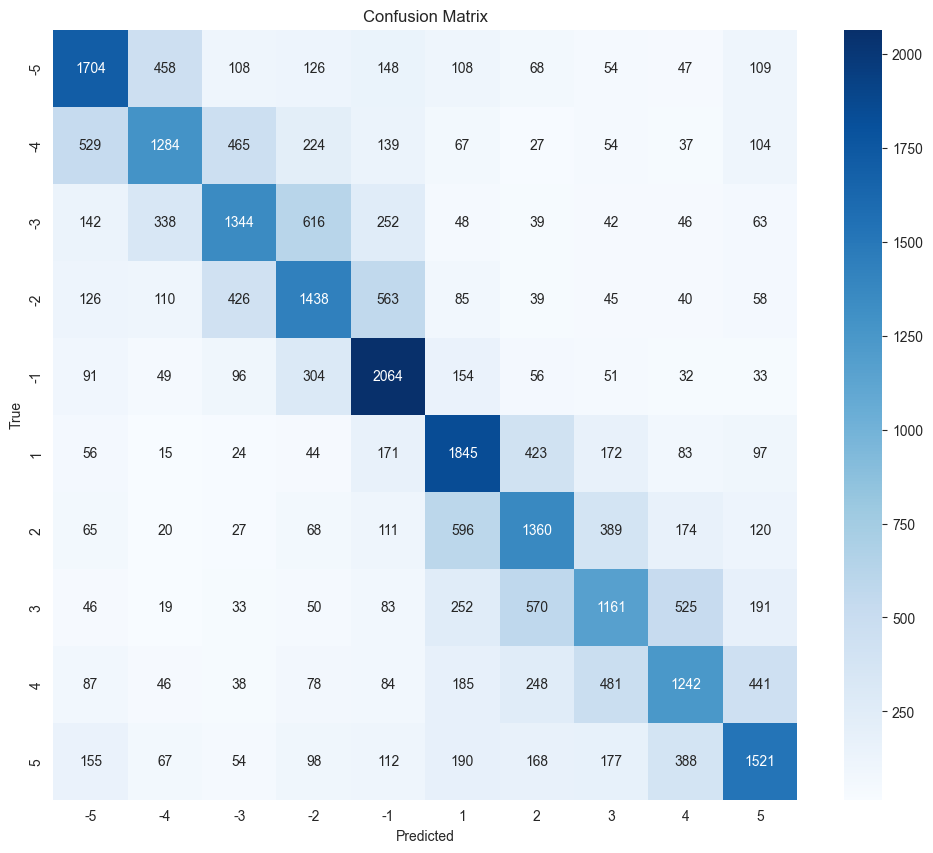

In [74]:
# 绘制混淆矩阵
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_fingering.classes_, yticklabels=le_fingering.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()